In [36]:
#  MNIST Digit Classification with TensorFlow
# tr: TensorFlow ile MNIST Rakam Sınıflandırma

In [37]:
# Bu konu, MNIST veri seti üzerinde basit bir yapay zekâ modeli (derin öğrenme) eğitmek için hazırlanmıştır. 
# Eğitim ve test verilerini yükleme, ön işleme, One-Hot Encoding ve eğitim-doğrulama ayrımı gibi adımlar Jupyter 
# Notebook ortamında adım adım gösterilmiştir.

In [38]:
# Bu konu altında yapılan işlemler:
#
# MNIST veri setini yükleme: keras.datasets.mnist modülü üzerinden eğitim ve test verileri alınır.
# Veri boyutlandırma: Görüntüler (28x28) ve kanal sayısı (reshape(-1,28,28,1)) ayarlanır.
# Normalizasyon: Piksel değerleri 0-1 aralığına getirilir (astype('float32') / 255.0).
# Görselleştirme: Örnek bir eğitim görüntüsü plt.imshow() ile gösterilir.
# One-Hot Encoding: Etiketler (y_train ve y_test) yapay zekâ modelinin anlayacağı şekilde kategorik verilere çevrilir.
# Eğitim-Doğrulama Ayrımı: train_test_split ile eğitim verisinin %20’si doğrulama (validation) olarak ayrılır.



# Kullanım Alanları:
# El yazısı rakam tanıma (digit recognition)
# Basit derin öğrenme model eğitim ve test uygulamaları
# Eğitim verisi ön işleme ve görselleştirme örnekleri
# TensorFlow / Keras ile sınıflandırma uygulamaları


In [39]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [40]:
# MNIST veri setini keras modülü üzerinden indir.

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [41]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [42]:
# Eğitim ve test görüntülerini yeniden boyutlandırıyoruz (kanal sayısı için)

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
# -1 parametresi, verinin kendi sayısını ifade eder
# yani biz 60000 ya da 10000 yazmak yerine -1 yazınca, kod bunu anlıyor zaten

# Görüntüleri normalize ediyoruz (0 ila 1 arasında ifade ediyoruz-pikselleri)

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Şimdi, ön işlemeden sonra görüntünün toplam sayısını ve kanalını gösterelim

print(f"Eğitim görüntüsü sayısı ve boyutu = {x_train.shape}")
print(f"Test görüntüsü sayısı ve boyutu = {x_test.shape}")

Eğitim görüntüsü sayısı ve boyutu = (60000, 28, 28, 1)
Test görüntüsü sayısı ve boyutu = (10000, 28, 28, 1)


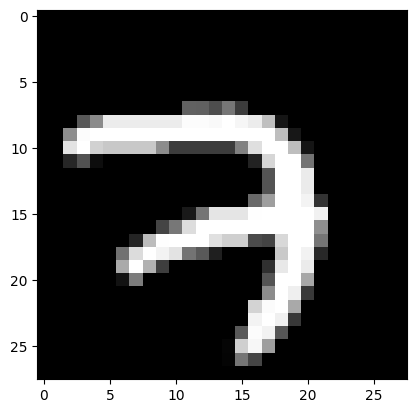

In [43]:
# Görüntüyü (x_train) ve onun etiketini (y_train)
# Görüntüler (Eğitim) x_train değişkeninde, onun etiketi ise y_train değişkeninde

plt.imshow(x_train[5000],cmap="gray")

In [44]:
y_train[5000]

np.uint8(7)

In [45]:
# Hem eğitim hem de test verilerinin bilgisinin yani etiketinin tutulduğu
# y_train ve y_test değişkenlerinde sadece rakam bilgisi yer alıyor
# yukarıda da görüldüğü

# Ancak, yapay zekâ modelimize bunu aktarmadan önce modelin anlayabileceği
# hale getirmemiz lazım

# Nümerik verilerin bit seviyesinde kategorik verilere dönüştürülmesine
# One-Hot encoding işlemi denir. Biz de şimdi aşağıda one-hot encoding
# işlemi yapacağız

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [46]:
y_train[5000]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [47]:
# Şimdi de eğitim verisi içerisinde eğitim-doğrulama verisi (train-validation)
# ayrımını yapıyoruz

# Eğitim verisinin bir kısmını (%20'sini) doğrulama olarak seçiyoruz
# Bunu, yukarıda import ettiğimiz train_test_split metoduyla yapacağız
# NOT: yukarıda ilk veri setini aldığımızda küçük harfle x_ yapmıştık
# aşağıda ise büyük harfle X_ yapacağız

X_train, X_val, y_train_split, y_val = train_test_split(
    x_train, y_train,#yukarıdaki veri ayrımını x_train ve y_train'den çekiyoruz
    test_size=0.2, # validation data olarak eğitimin yüzde 20'si alınsın
    random_state=42, # verileri split yaparken (ayırırken) bellir bir 
    # rassallığa sadık kalacak (bir sonraki ayrım işleminde de aynı değerleri
    # verirsek, aynı verileri ayıracak)
    stratify=y_train # etiket sayısına sadık kalarak buna oranla
    # bir ayrım işlemi yapacak
)

In [55]:
model = keras.Sequential([

    keras.layers.Input(shape=(28,28,1)),   # <-- burayı 28x28 yap

    keras.layers.Conv2D(32, (3,3), activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32,(3,3),activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(512,activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(10, activation="softmax"),
])


In [56]:
model.summary()

# Modeli derleme
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 24, 24, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 24, 24, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 10, 10, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 10, 10, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 8, 8, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 597,738 (2.28 MB)

 Trainable params: 596,330 (2.27 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [57]:
# Model checkpoint callback
my_callbacks = keras.callbacks.ModelCheckpoint(
    "my_mnist_classifier.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

# Modeli eğitme
history = model.fit(
    X_train, y_train_split,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=10,  # 0 yerine örnek olarak 10 epoch
    callbacks=[my_callbacks],
    verbose=1
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8726 - loss: 0.4412

375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 96ms/step - accuracy: 0.9413 - loss: 0.1951 - val_accuracy: 0.1689 - val_loss: 4.2972
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9789 - loss: 0.0656

375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.9797 - loss: 0.0626 - val_accuracy: 0.9890 - val_loss: 0.0366
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.9850 - loss: 0.0482 - val_accuracy: 0.9885 - val_loss: 0.0355
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9881 - loss: 0.0361

375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 101ms/step - accuracy: 0.9872 - loss: 0.0379 - val_accuracy: 0.9893 - val_loss: 0.0349
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9898 - loss: 0.0316

375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 96ms/step - accuracy: 0.9888 - loss: 0.0338 - val_accuracy: 0.9915 - val_loss: 0.0291
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9905 - loss: 0.0289

375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 112ms/step - accuracy: 0.9899 - loss: 0.0312 - val_accuracy: 0.9928 - val_loss: 0.0261
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.9909 - loss: 0.0273 - val_accuracy: 0.9921 - val_loss: 0.0270
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9917 - loss: 0.0247

375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - accuracy: 0.9912 - loss: 0.0271 - val_accuracy: 0.9933 - val_loss: 0.0232
Epoch 9/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9924 - loss: 0.0217

375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.9918 - loss: 0.0229 - val_accuracy: 0.9934 - val_loss: 0.0247
Epoch 10/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 93ms/step - accuracy: 0.9931 - loss: 0.0213 - val_accuracy: 0.9931 - val_loss: 0.0251


In [58]:
# Test verisi ile değerlendirme
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test verisinin doğruluk oranı: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9933 - loss: 0.0203
Test verisinin doğruluk oranı: 0.9933


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


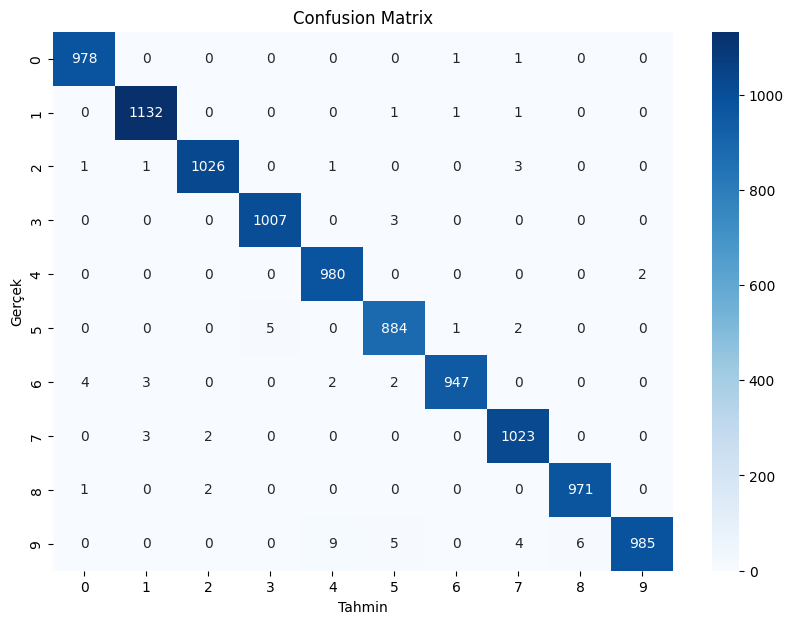

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      1.00      1.00       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [59]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Tahmin yapma
y_pred = model.predict(x_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_test_class = np.argmax(y_test, axis=1)

# Confusion matrix oluşturma
cm = confusion_matrix(y_test_class, y_pred_class)

# Confusion matrix görselleştirme
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_test_class, y_pred_class))


In [60]:
# Özet:
# Bu notebook, MNIST veri seti ile çalışarak bir yapay zekâ modelinin veri yükleme, ön işleme ve eğitim sürecini adım adım göstermektedir.
# Görüntüler yeniden boyutlandırılır ve normalize edilir.
# Etiketler One-Hot Encoding ile kategorik hale getirilir.
# Eğitim verisinin bir kısmı doğrulama için ayrılır.
# Bu adımlar, derin öğrenme modellerinin doğru ve verimli bir şekilde eğitim almasını sağlar.
